# IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from pmdarima import auto_arima, ARIMA, model_selection
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import  ParameterGrid
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
import seaborn as sns


# Import data and perform cleaning

In [2]:
df= pd.read_csv(r"C:\Users\MINE\Desktop\Nigerian Stock Exchange (NGX) All-Share Index\NSE All Share Historical Data (1).csv",
index_col = "Date",
                 parse_dates = True,
                 dayfirst = True)

In [3]:
df.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2026-02-10,"176,805.95","173,946.22","177,094.23","173,937.91",1.05B,1.64%
2026-02-09,"173,952.06","171,727.48","173,952.69","171,577.58",775.06M,1.30%
2026-02-06,"171,727.48","170,008.02","171,810.48","170,002.31",953.71M,1.01%
2026-02-05,"170,005.36","168,040.80","170,052.27","168,032.50",712.94M,1.18%
2026-02-04,"168,030.19","165,901.56","168,037.55","165,901.56",694.76M,1.28%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3474 entries, 2026-02-10 to 2012-01-30
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Price     3474 non-null   object
 1   Open      3474 non-null   object
 2   High      3474 non-null   object
 3   Low       3474 non-null   object
 4   Vol.      2177 non-null   object
 5   Change %  3474 non-null   object
dtypes: object(6)
memory usage: 190.0+ KB


In [5]:
df.drop(columns='Vol.', inplace=True)

In [6]:
df=df.rename(columns={'Price': 'y'})

In [7]:
df.head()

,y,Open,High,Low,Change %
Date,,,,,
2026-02-10,"176,805.95","173,946.22","177,094.23","173,937.91",1.64%
2026-02-09,"173,952.06","171,727.48","173,952.69","171,577.58",1.30%
2026-02-06,"171,727.48","170,008.02","171,810.48","170,002.31",1.01%
2026-02-05,"170,005.36","168,040.80","170,052.27","168,032.50",1.18%
2026-02-04,"168,030.19","165,901.56","168,037.55","165,901.56",1.28%


In [8]:
col= ['y', 'Open', 'High', 'Low', ]
for col in col:
  df[col]= df[col].str.replace(',','').astype('float64')


  

In [9]:
df['Change %']= df['Change %'].str.replace('%', '').astype('float64')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3474 entries, 2026-02-10 to 2012-01-30
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   y         3474 non-null   float64
 1   Open      3474 non-null   float64
 2   High      3474 non-null   float64
 3   Low       3474 non-null   float64
 4   Change %  3474 non-null   float64
dtypes: float64(5)
memory usage: 162.8 KB


In [11]:
df= df.asfreq('B')

# Setting the frequency would filter out holidays so we have to drop holidays

In [12]:
df.isnull().sum()

y           188
Open        188
High        188
Low         188
Change %    188
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.sort_values('Date', inplace=True)

In [15]:
df.head()

,y,Open,High,Low,Change %
Date,,,,,
2012-01-30,20731.72,20939.10,20950.02,20731.72,-0.77
2012-01-31,20875.83,20818.56,21009.92,20789.48,0.70
2012-02-01,20790.88,20875.34,20941.03,20790.88,-0.41
2012-02-02,20822.00,20872.94,20900.58,20785.40,0.15
2012-02-03,20877.64,20822.00,20863.93,20786.35,0.27


In [16]:
df.index = pd.to_datetime(df.index) 

In [17]:
df.index

DatetimeIndex(['2012-01-30', '2012-01-31', '2012-02-01', '2012-02-02',
               '2012-02-03', '2012-02-07', '2012-02-08', '2012-02-09',
               '2012-02-10', '2012-02-13',
               ...
               '2026-01-28', '2026-01-29', '2026-01-30', '2026-02-02',
               '2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06',
               '2026-02-09', '2026-02-10'],
              dtype='datetime64[ns]', name='Date', length=3474, freq=None)

# Exploratory Data Analysis 

`.resample()` offset aliases:
- B = business day
- D = calendar day
- W = weekly
- M = month end
- BM = business month end
- MS = month start
- BMS = business month start
- Q = quarter end
- BQ = business quarter end
- QS = quarter start
- BQS = business quarter start
- A = year end
- BA = business year end
- AS = year start
- BAS = business year start
- h = hourly
- min = minutely
- s = secondly
- ms = milliseconds
- us = microseconds

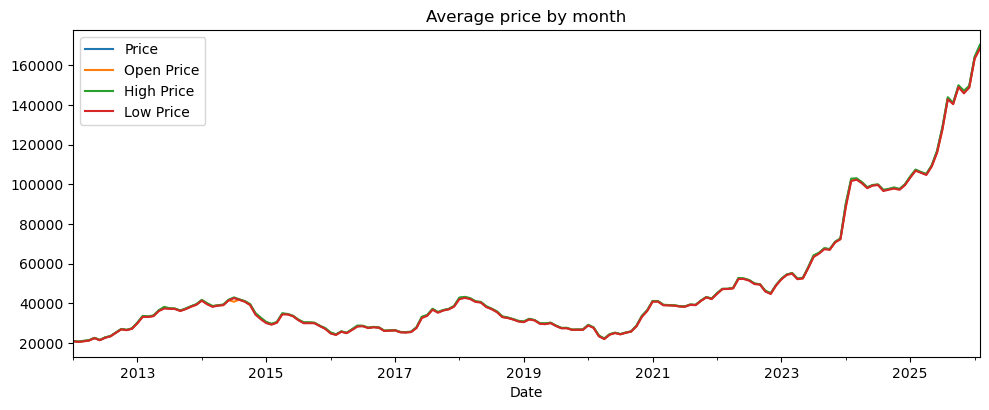

In [18]:
plt.figure(figsize=(10,4))

df.y.resample('ME').mean().plot(label= 'Price')
df.Open.resample('ME').mean().plot(label= 'Open Price')
df.High.resample('ME').mean().plot(label= 'High Price')
df.Low.resample('ME').mean().plot(label= 'Low Price')

plt.tight_layout()
plt.legend()
plt.title('Average price by month')
plt.show()

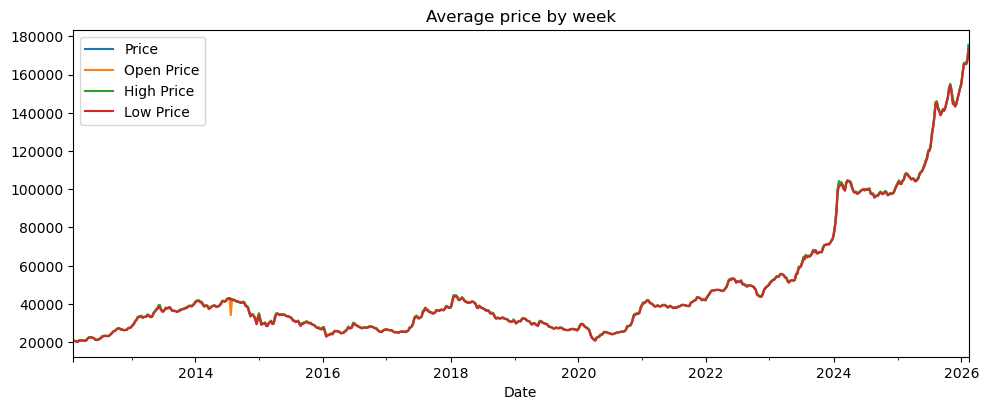

In [19]:
plt.figure(figsize=(10,4))

df.y.resample('W').mean().plot(label= 'Price')
df.Open.resample('W').mean().plot(label= 'Open Price')
df.High.resample('W').mean().plot(label= 'High Price')
df.Low.resample('W').mean().plot(label= 'Low Price')

plt.tight_layout()
plt.legend()
plt.title('Average price by week')
plt.show()

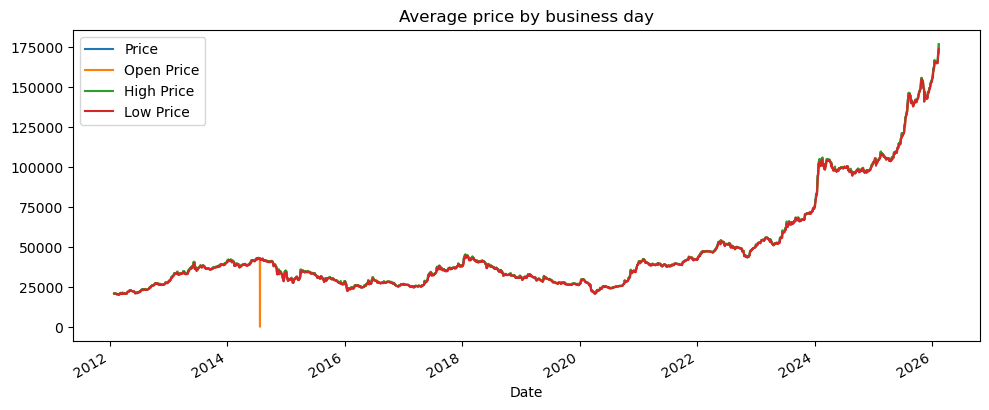

In [20]:
plt.figure(figsize=(10,4))

df.y.plot(label= 'Price')
df.Open.plot(label= 'Open Price')
df.High.plot(label= 'High Price')
df.Low.plot(label= 'Low Price')

plt.tight_layout()
plt.legend()
plt.title('Average price by business day')
plt.show()

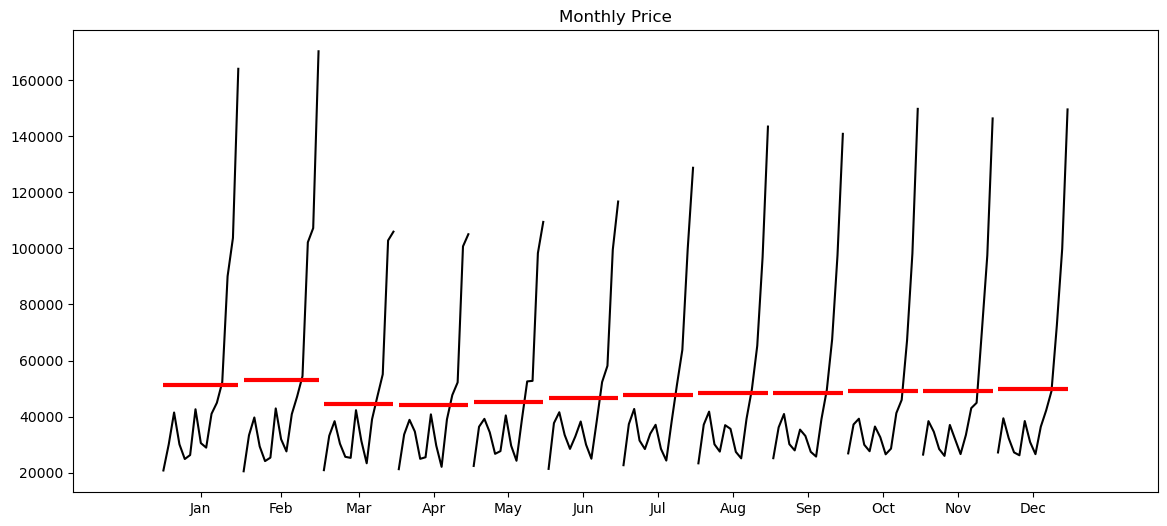

In [21]:

month_plot(df.y.resample('ME').mean()).set_size_inches(14,6)


plt.title('Monthly Price')
plt.show()


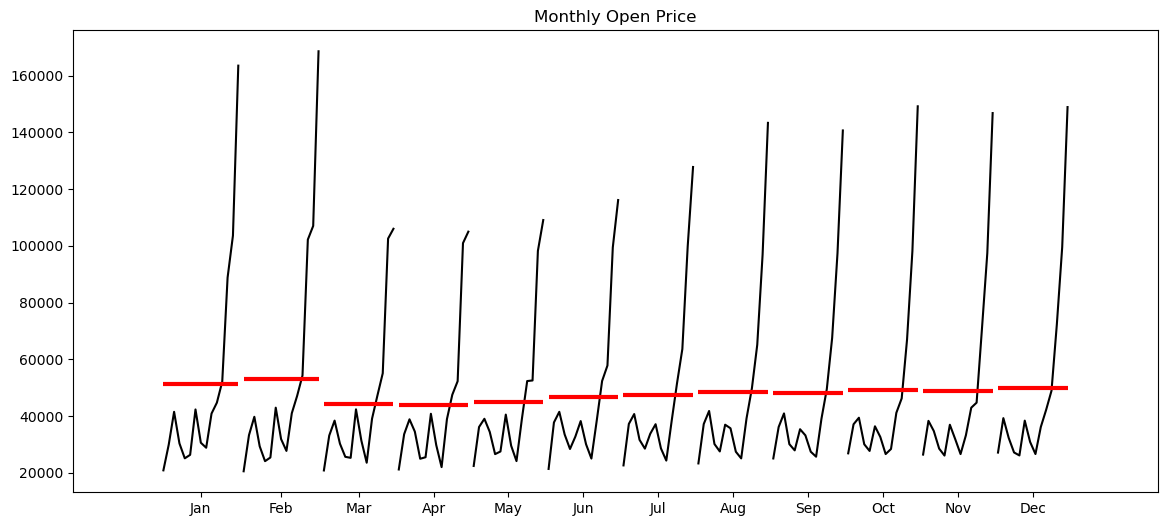

In [22]:

month_plot(df.Open.resample('ME').mean()).set_size_inches(14,6)


plt.title('Monthly Open Price')
plt.show()

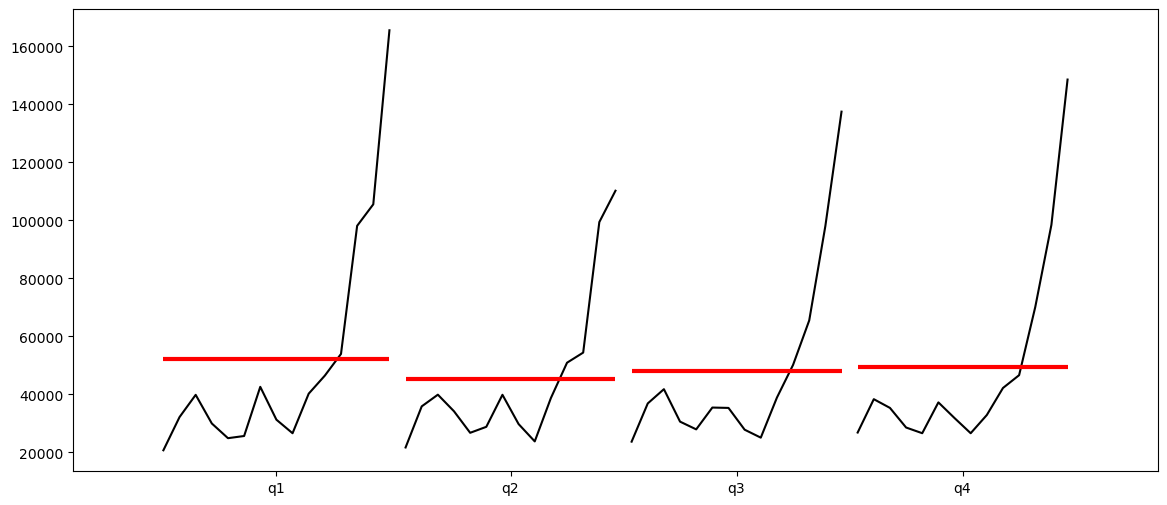

In [23]:
quarter_plot(df.y.resample('QE').mean()).set_size_inches(14,6)

plt.show()

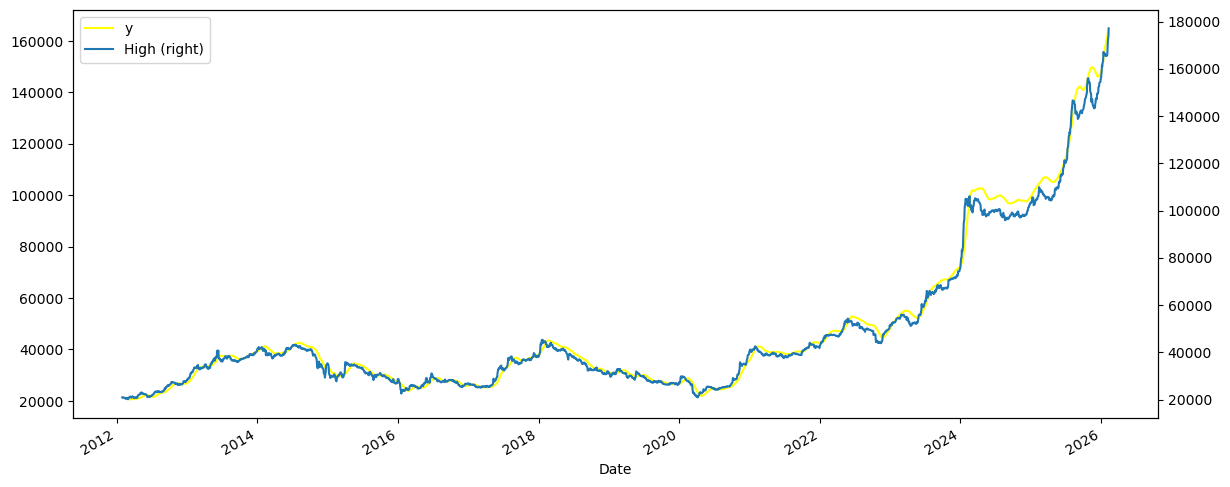

In [24]:
# Plot closing price and 30 day rolling volume
plt.figure(figsize=(14, 6))
df.y.rolling(window=30).mean().plot(legend= True, color= 'yellow')

df.High.plot(secondary_y= True, legend= True)

plt.show()

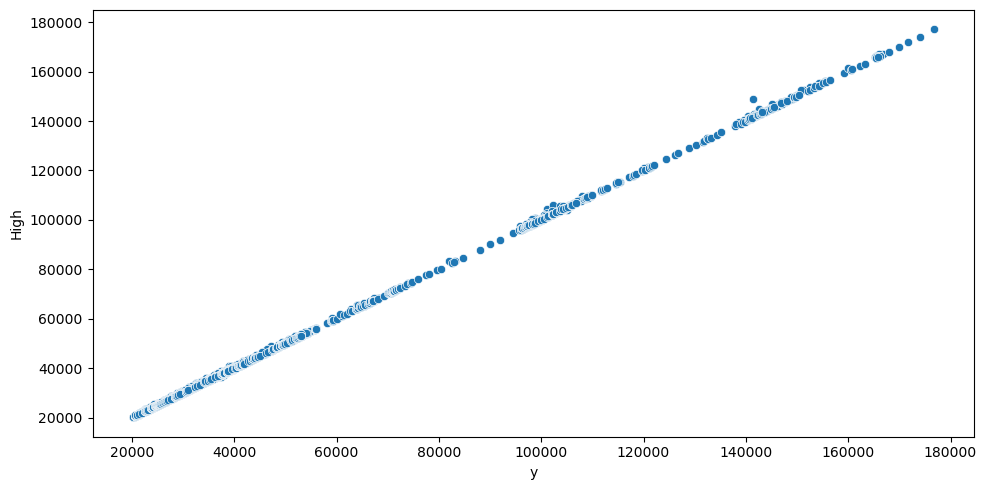

In [25]:
plt.figure(figsize=(10,5))

sns.scatterplot(x= df.y, y=df.High, data=df)
plt.tight_layout()
plt.show()

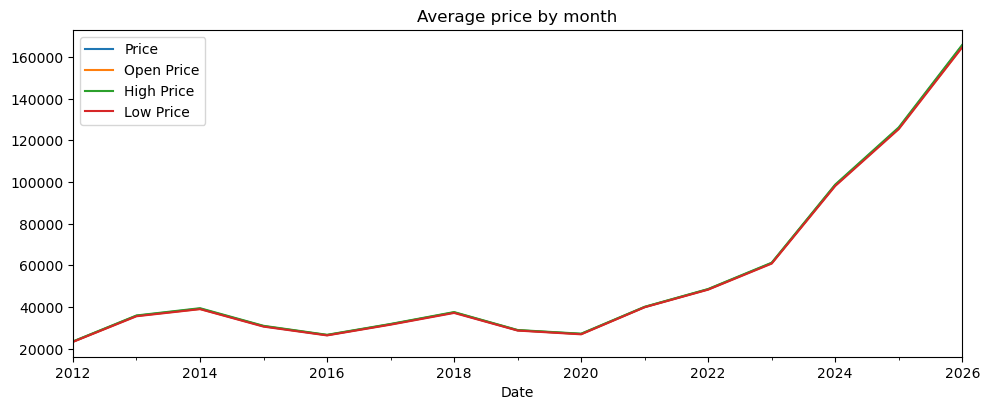

In [26]:
plt.figure(figsize=(10,4))

df.y.resample('YE').mean().plot(label= 'Price')
df.Open.resample('YE').mean().plot(label= 'Open Price')
df.High.resample('YE').mean().plot(label= 'High Price')
df.Low.resample('YE').mean().plot(label= 'Low Price')

plt.tight_layout()
plt.legend()
plt.title('Average price by month')
plt.show()

In [27]:
decompose = seasonal_decompose(df.y, model='mul', period=260)

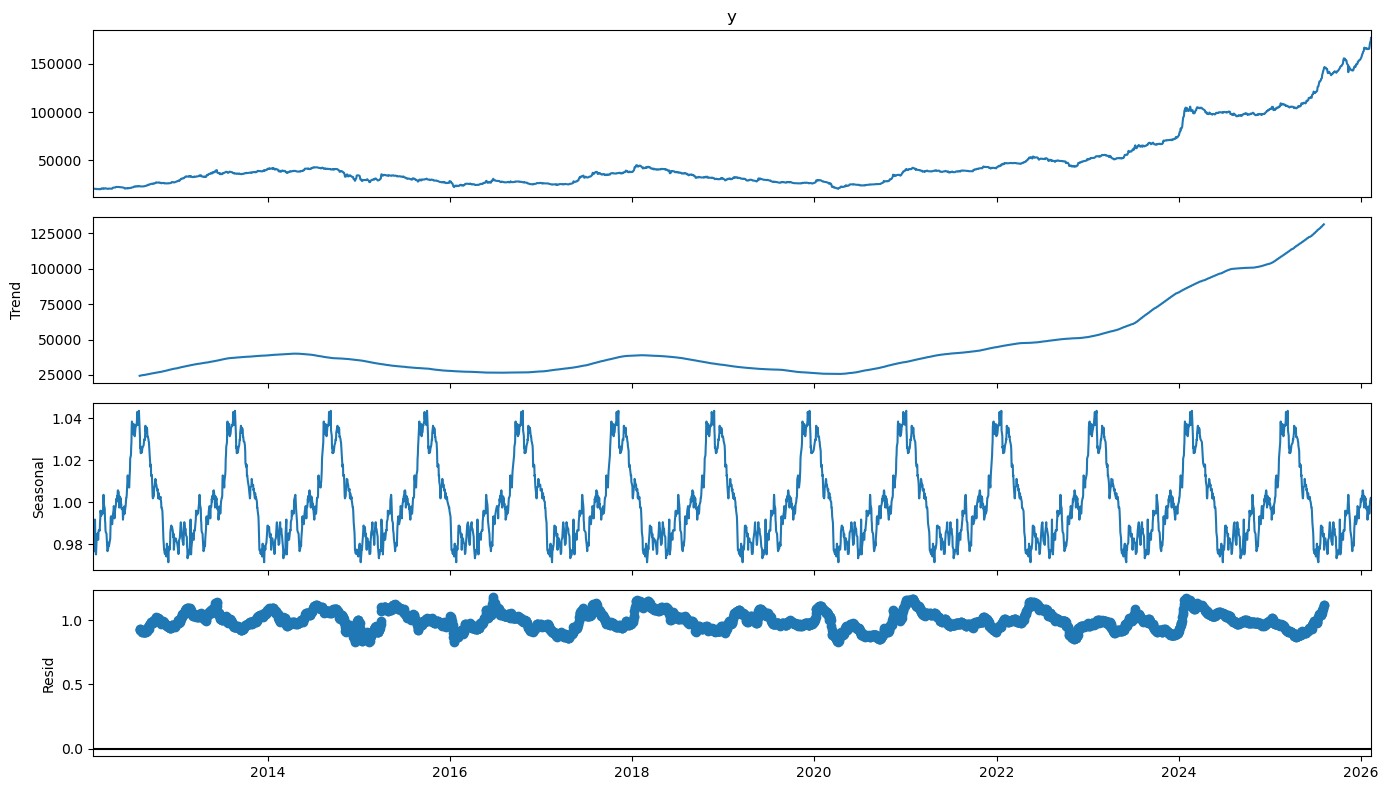

In [28]:
decompose.plot().set_size_inches(14,8)

plt.tight_layout()

plt.show()
    

In [29]:
corr= df.corr()

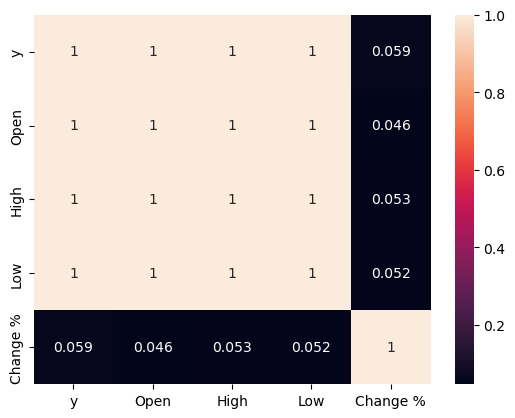

In [30]:
sns.heatmap(corr, annot=True)

plt.show()

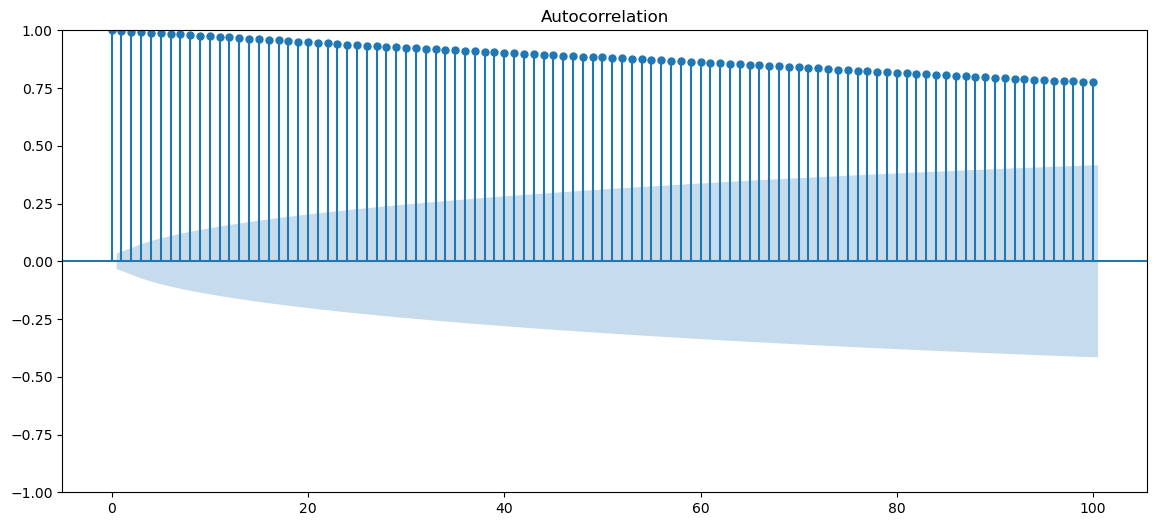

In [31]:
plot_acf(df.y, lags=100).set_size_inches(14,6)

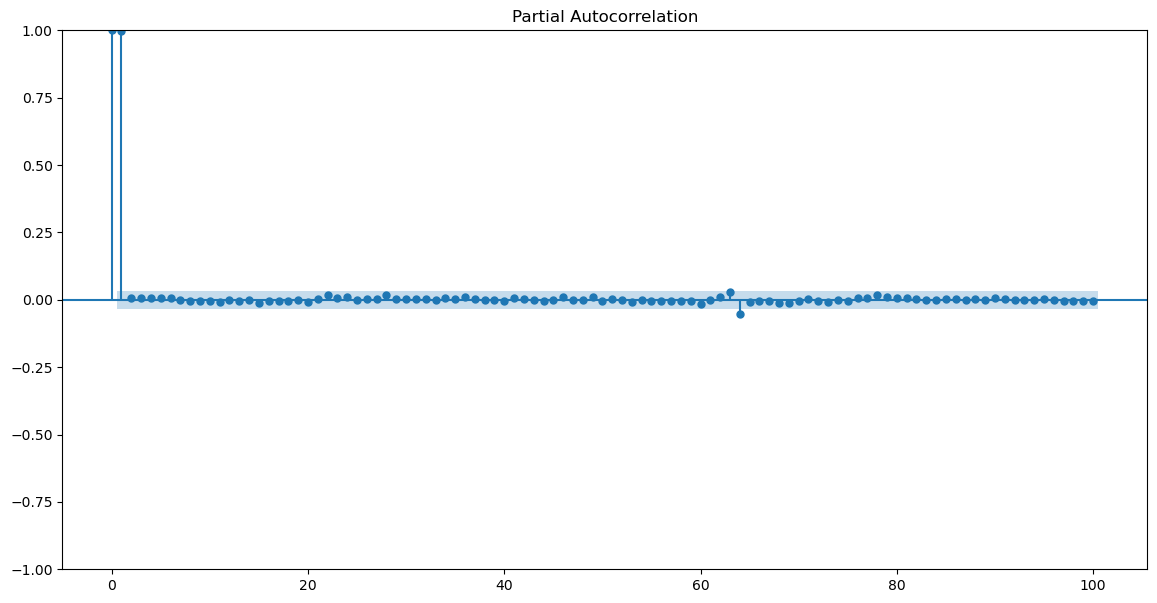

In [32]:
plot_pacf(df.y, lags=100).set_size_inches(14,7)

In [33]:
df.head()

,y,Open,High,Low,Change %
Date,,,,,
2012-01-30,20731.72,20939.10,20950.02,20731.72,-0.77
2012-01-31,20875.83,20818.56,21009.92,20789.48,0.70
2012-02-01,20790.88,20875.34,20941.03,20790.88,-0.41
2012-02-02,20822.00,20872.94,20900.58,20785.40,0.15
2012-02-03,20877.64,20822.00,20863.93,20786.35,0.27


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3474 entries, 2012-01-30 to 2026-02-10
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   y         3474 non-null   float64
 1   Open      3474 non-null   float64
 2   High      3474 non-null   float64
 3   Low       3474 non-null   float64
 4   Change %  3474 non-null   float64
dtypes: float64(5)
memory usage: 162.8 KB


In [35]:
df= df.sort_index()

In [36]:
df.head()

,y,Open,High,Low,Change %
Date,,,,,
2012-01-30,20731.72,20939.10,20950.02,20731.72,-0.77
2012-01-31,20875.83,20818.56,21009.92,20789.48,0.70
2012-02-01,20790.88,20875.34,20941.03,20790.88,-0.41
2012-02-02,20822.00,20872.94,20900.58,20785.40,0.15
2012-02-03,20877.64,20822.00,20863.93,20786.35,0.27


In [37]:
df = df.asfreq('B') 

In [38]:
print(df.index)
print(df.index.freq)
print(pd.infer_freq(df.index))

DatetimeIndex(['2012-01-30', '2012-01-31', '2012-02-01', '2012-02-02',
               '2012-02-03', '2012-02-06', '2012-02-07', '2012-02-08',
               '2012-02-09', '2012-02-10',
               ...
               '2026-01-28', '2026-01-29', '2026-01-30', '2026-02-02',
               '2026-02-03', '2026-02-04', '2026-02-05', '2026-02-06',
               '2026-02-09', '2026-02-10'],
              dtype='datetime64[ns]', name='Date', length=3662, freq='B')
<BusinessDay>
B


In [40]:
# Split the Data into training and test
train, test = df.iloc[:-90, : ], df.iloc[-90:, :]
test.head()

,y,Open,High,Low,Change %
Date,,,,,
2025-10-08,145719.09,145024.00,145784.45,144986.44,0.50
2025-10-09,146204.31,145984.94,146204.31,145984.94,0.33
2025-10-10,146988.05,146204.34,147107.19,146098.25,0.54
2025-10-13,147717.20,146987.09,147717.20,146884.31,0.50
2025-10-14,147710.95,147715.50,147873.80,147626.77,0.00


In [41]:
train.head()

,y,Open,High,Low,Change %
Date,,,,,
2012-01-30,20731.72,20939.10,20950.02,20731.72,-0.77
2012-01-31,20875.83,20818.56,21009.92,20789.48,0.70
2012-02-01,20790.88,20875.34,20941.03,20790.88,-0.41
2012-02-02,20822.00,20872.94,20900.58,20785.40,0.15
2012-02-03,20877.64,20822.00,20863.93,20786.35,0.27


# Exponential Smoothening

In [42]:
model= ExponentialSmoothing(train.y.ffill(),
                                  trend= 'add',
                                  seasonal='add',
                                  seasonal_periods= 300,
                                  initialization_method='estimated').fit()

In [43]:
print(model.mle_retvals)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 584934509.9235699
        x: [ 1.000e+00  1.469e-01 ...  8.413e+02  7.583e+02]
      nit: 7
      jac: [-6.318e+08 -8.917e+03 ...  6.557e+02  5.960e+03]
     nfev: 4284
     njev: 14
 hess_inv: <305x305 LbfgsInvHessProduct with dtype=float64>


In [44]:
model.summary()

Dep. Variable:,y,No. Observations:,3572
Model:,ExponentialSmoothing,SSE,584934509.924
Optimized:,True,AIC,43493.895
Trend:,Additive,BIC,45372.882
Seasonal:,Additive,AICC,43551.439
Seasonal Periods:,300,Date:,"Fri, 06 Mar 2026"
Box-Cox:,False,Time:,08:20:38
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,1.0000000,alpha,True
smoothing_trend,0.1468928,beta,True


In [45]:
predictions= model.forecast(len(test))

In [46]:
def model_evaluator(train, test, prediction, model_name):
  plt.figure(figsize=(10,4))
  plt.plot(train, label= 'train')
  plt.plot(test, label= 'test')
  plt.plot(prediction, label= 'predictions')
  plt.tight_layout()
  plt.legend()
  plt.title(f'Train Test And Prediction With {model_name}')
  plt.show()

  mape = round(mean_absolute_percentage_error(test, prediction), 2)
  r2score= r2_score(test, prediction)
  mae= round(mean_absolute_error(test, prediction), 2)
  msq= round(mean_squared_error(test, prediction), 2)
  rmse= round(root_mean_squared_error(test, prediction))
  print(f'the mean absolute error is {mean_absolute_error(test,prediction)}')
  print(f'the mean absolute percentage is { 100 * (mean_absolute_percentage_error(test, prediction))} %')
  print(f'The root mean squared error is { root_mean_squared_error(test, prediction)}')
  print(f'the r2_score is {r2_score(test, prediction)}')

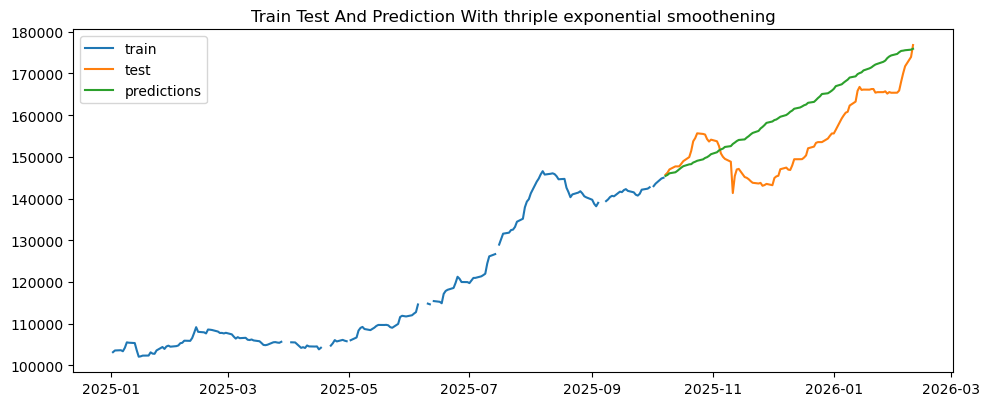

the mean absolute error is 7665.4313261598645
the mean absolute percentage is 5.038250426931904 %
The root mean squared error is 8776.576244035672
the r2_score is -0.0342117674880833


In [47]:
model_evaluator(train.y.loc['2025'], test.y.ffill(), predictions, 'thriple exponential smoothening')

In [48]:
exog_train= train.iloc[:, 1:4]
exog_test= test.iloc[:, 1:4]

In [49]:
model_sarimax= auto_arima(y= train.y.ffill(),
                          x= exog_train.ffill(),
                          m= 20,
                          seasonal=True,
                          stationary= True,
                          D= 1,
                          d= 1 ,
                          max_d= 2,
                          start_p= 1, max_p=4,
                          start_q=1,  max_q=4,
                          start_P=1, max_P= 4,
                          start_Q=1, max_Q=4,
                    
                          maxiter=100,              
                          stepwise=True,            
                          trace=True,               
                          information_criterion='aic', 
                          suppress_warnings=True,
                          error_action='ignore')

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[20] intercept   : AIC=inf, Time=54.10 sec
 ARIMA(0,0,0)(0,0,0)[20] intercept   : AIC=82887.283, Time=0.85 sec
 ARIMA(1,0,0)(1,0,0)[20] intercept   : AIC=inf, Time=42.69 sec
 ARIMA(0,0,1)(0,0,1)[20] intercept   : AIC=inf, Time=16.76 sec
 ARIMA(0,0,0)(0,0,0)[20]             : AIC=87763.333, Time=0.57 sec
 ARIMA(0,0,0)(1,0,0)[20] intercept   : AIC=82037.186, Time=3.40 sec
 ARIMA(0,0,0)(2,0,0)[20] intercept   : AIC=inf, Time=nan sec
 ARIMA(0,0,0)(1,0,1)[20] intercept   : AIC=inf, Time=9.21 sec
 ARIMA(0,0,0)(0,0,1)[20] intercept   : AIC=inf, Time=18.04 sec
 ARIMA(0,0,0)(2,0,1)[20] intercept   : AIC=inf, Time=165.57 sec
 ARIMA(0,0,1)(1,0,0)[20] intercept   : AIC=inf, Time=23.75 sec
 ARIMA(1,0,1)(1,0,0)[20] intercept   : AIC=52839.584, Time=59.82 sec
 ARIMA(1,0,1)(0,0,0)[20] intercept   : AIC=52839.341, Time=9.22 sec
 ARIMA(1,0,1)(0,0,1)[20] intercept   : AIC=52839.602, Time=54.76 sec
 ARIMA(0,0,1)(0,0,0)[20] intercept   : AIC=in

In [54]:
model_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 3572
Model:               SARIMAX(3, 0, 2)   Log Likelihood              -26353.799
Date:                Fri, 06 Mar 2026   AIC                          52721.599
Time:                        08:57:53   BIC                          52764.865
Sample:                    01-30-2012   HQIC                         52737.024
                         - 10-07-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.6623      2.146      0.309      0.758      -3.545       4.869
ar.L1          2.0383      0.070     29.167      0.000       1.901       2.175
ar.L2         -1.1353      0.131     -8.671      0.000      -1.392      -0.879
ar.L3          0.0970      0.061      1.583      0.113      -0.023       0.217
ma.L1         -0.7639      0.070    -10.920      0.000      -0.901      -0.627
ma.L2         -0.0869      0.051     -1.688      0.091      -0.188       0.014
sigma2      1.495e+05   1.52e-05    9.8e+09      0.000    1.49e+05    1.49e+05
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             16548.09
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               2.88   Skew:                             0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.54
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.89e+26. Standard errors may be unstable.
"""

In [55]:
sarimax_forecast= model_sarimax.predict(len(test), x= exog_test.ffill())

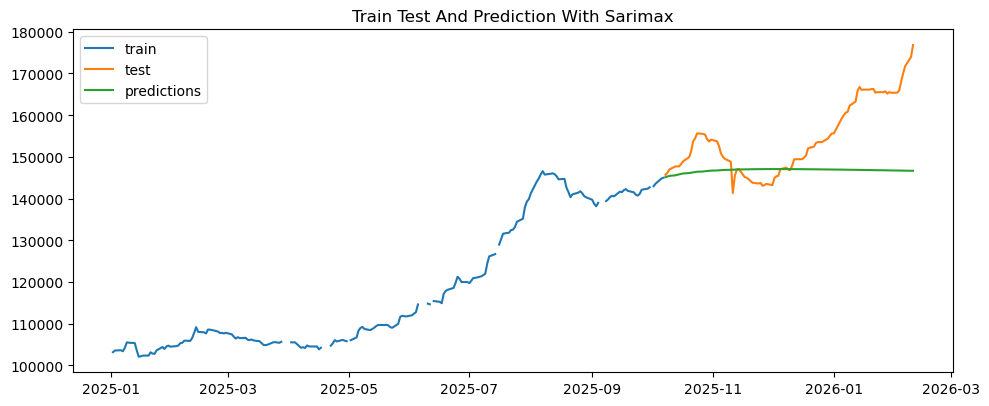

the mean absolute error is 8548.24007881322
the mean absolute percentage is 5.302108203571046 %
The root mean squared error is 11431.196367511093
the r2_score is -0.7544564217217695


In [56]:
model_evaluator(train.y.loc['2025'], test.y.ffill(),sarimax_forecast, 'Sarimax')

In [57]:
model= auto_arima(y= train.y.ffill(), x= exog_train.ffill(), seasonal= True, m= 5)

In [58]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                                 y   No. Observations:                 3572
Model:             SARIMAX(0, 2, 1)x(2, 0, 1, 5)   Log Likelihood              -26454.749
Date:                           Fri, 06 Mar 2026   AIC                          52919.497
Time:                                   09:03:44   BIC                          52950.399
Sample:                               01-30-2012   HQIC                         52930.514
                                    - 10-07-2025                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8721      0.005   -185.131      0.000      -0.881      -0.863
ar.S.L5        0.6935      0.112      6.215      0.000       0.475       0.912
ar.S.L10      -0.0317      0.011     -2.852      0.004      -0.053      -0.010
ma.S.L5       -0.7042      0.112     -6.297      0.000      -0.923      -0.485
sigma2      1.576e+05   1554.148    101.427      0.000    1.55e+05    1.61e+05
===================================================================================
Ljung-Box (L1) (Q):                 100.79   Jarque-Bera (JB):             14803.15
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.56   Skew:                            -0.31
Prob(H) (two-sided):                  0.00   Kurtosis:                        12.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""